In [10]:
import matplotlib.pyplot as plt
import numpy as np

USANDO UMA REDE NEURAL PARA APRENDER A RELAÇÂO A TEMPERATURA X TEMPO EM FLUIDOS, BASEADO NA LEI DE RESFRIAMENTO DE NEWTON

In [11]:
#Geração dos dados experimentais
T0 = 37.5 #ºC
k = 0.3
Tamb = 25 #ºC

def T(t,k,T0,Tamb):

    T =  Tamb + (T0 - Tamb) * np.exp(-k*t)
    return T

tempo = np.linspace(0,60,100)

dados_experimentais = T(tempo,k,T0,Tamb)

In [12]:
#Funções de ativação
def sigmoid(x):
    return 1 / (1+np.exp(-x))

def ReLU(x):
    return np.maximum(0,x)

def ReLU_deriv(x):
    return (x > 0).astype(float)
    
def sigmoid_deriv(x):
    return sigmoid(x) * (1-sigmoid(x))


In [13]:
#Normalização dos dados:

def MaxMin(X:np.ndarray):
    return (X - np.min(X)) / (np.max(X) - np.min(X))
def Desnorm_MaxMin(X_norm:np.ndarray, X:np.ndarray):
    return X_norm *(np.max(X) - np.min(X)) + np.min(X)

X = tempo.reshape(-1,1)
Y = dados_experimentais.reshape(-1,1)

X_norm = MaxMin(X)
Y_norm = MaxMin(Y)

In [14]:

learning_rate = 0.1
epochs = 10000 



W1 = np.random.randn(1,4)
b1 = np.zeros((1,4))
W2 = np.random.randn(4,1)
b2 = np.zeros((1,1))

for epoch in range(epochs):
    # FORWARD PASS 
    Z1 = np.dot(X_norm, W1) + b1
    A1 = ReLU(Z1)
    
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    # LOSS 
    loss = np.mean((A2 - Y_norm)**2)

    # BACKPROPAGATION
    # Camada de Saída
    dZ2 = 2 * (A2 - Y_norm) * sigmoid_deriv(Z2)
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Camada Oculta
    dZ1 = np.dot(dZ2, W2.T) * ReLU_deriv(Z1) 
    dW1 = np.dot(X_norm.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    
    #  ATUALIZAÇÃO
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1


(20.0, 40.0)

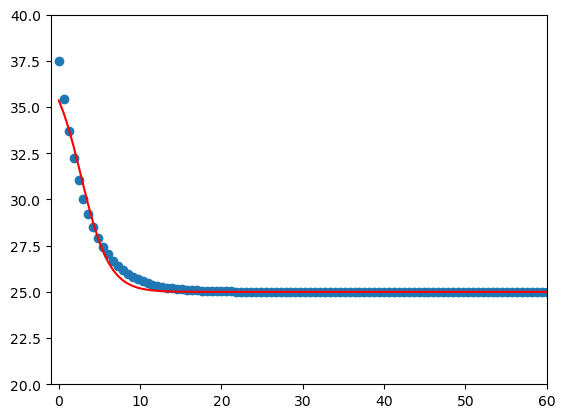

In [15]:
dados_rede = Desnorm_MaxMin(A2, dados_experimentais)

plt.scatter(tempo, dados_experimentais)
plt.plot(tempo, dados_rede, 'red')
plt.xlim((-1,60))
plt.ylim((20,40))


In [20]:
def prever_temperatura(tempo_input):
    global W1, W2, b1, b2, tempo, dados_experimentais
    
  
    t_min, t_max = np.min(tempo), np.max(tempo)
    tempo_norm = (tempo_input - t_min) / (t_max - t_min)
    

    tempo_norm = np.array([[tempo_norm]])
    

    z1 = np.dot(tempo_norm, W1) + b1
    a1 = ReLU(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)
    

    temp_prevista = Desnorm_MaxMin(a2, dados_experimentais)
    
    return temp_prevista[0][0]

# Testando
t_teste = 30
resultado = prever_temperatura(t_teste)
print(f"Previsão para t = {t_teste}: {resultado} °C")

print(T(30,k,T0,Tamb))

Previsão para t = 30: 25.000002164514004 °C
25.001542622551085
